In [ ]:
# Notebook Outline - Analyst 2 (Logistics & Delivery)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reading data from the correct path
orders = pd.read_csv(r"D:\Safa\SQL\project\archive (2)\olist_orders_dataset.csv")
customers = pd.read_csv(r"D:\Safa\SQL\project\archive (2)\olist_customers_dataset.csv")

# Display the first 5 rows to ensure the data was read correctly
print("Orders dataset:")
print(orders.head())

print("\nCustomers dataset:")
print(customers.head())

In [ ]:
### Step 1: Data Cleaning – Missing Values
This step identifies missing values in the dataset and filters undelivered orders for further analysis.

In [11]:
# Convert Date Columns to datetime
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

print(orders[date_columns].dtypes)

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [39]:
# Number of missing values in each column
print(orders.isnull().sum())

# Orders that have not yet been delivered
undelivered = orders[orders["order_delivered_customer_date"].isna()]
print("Number of undelivered orders:", len(undelivered))

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
Number of undelivered orders: 2965


In [25]:
#Exclude undelivered orders during analysis
delivered_orders = orders[(orders["order_status"] == "delivered") & (orders["order_delivered_customer_date"].notna())]

print("Number of orders delivered:", len(delivered_orders))

Number of orders delivered: 96470


In [26]:
# Standardize State Names
# Convert state names to Uppercase
customers["customer_state"] = customers["customer_state"].str.upper()

# Verification of Unity
print(customers["customer_state"].unique())


['SP' 'SC' 'MG' 'PR' 'RJ' 'RS' 'PA' 'GO' 'ES' 'BA' 'MA' 'MS' 'CE' 'DF'
 'RN' 'PE' 'MT' 'AM' 'AP' 'AL' 'RO' 'PB' 'TO' 'PI' 'AC' 'SE' 'RR']


In [32]:
# Convert date columns to datetime
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"], errors="coerce")
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"], errors="coerce")

# Filter delivered orders
delivered_orders = orders[(orders["order_status"] == "delivered") & (orders["order_delivered_customer_date"].notna())]

C:\Users\Best By\AppData\Local\Temp\ipykernel_6288\828019487.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivered_orders["delivery_diff"] = (


Average Delivery Delay (days): -11.875888877371203


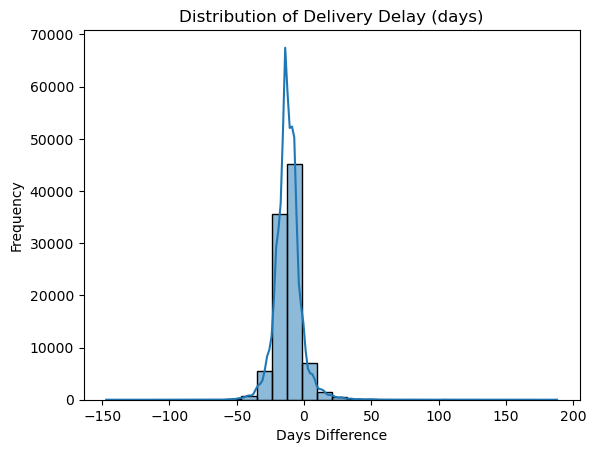

In [33]:
# Average Delivery Delay
delivered_orders["delivery_diff"] = (
    delivered_orders["order_delivered_customer_date"] - delivered_orders["order_estimated_delivery_date"]
).dt.days

avg_delay = delivered_orders["delivery_diff"].mean()
print("Average Delivery Delay (days):", avg_delay)

# Distribution chart
sns.histplot(delivered_orders["delivery_diff"].dropna(), bins=30, kde=True)
plt.title("Distribution of Delivery Delay (days)")
plt.xlabel("Days Difference")
plt.ylabel("Frequency")
plt.show()

     customer_state          customer_city  order_id
4138             SP              sao paulo     15045
2763             RJ         rio de janeiro      6601
1053             MG         belo horizonte      2697
598              DF               brasilia      2071
2387             PR               curitiba      1489
3692             SP               campinas      1406
3177             RS           porto alegre      1341
369              BA               salvador      1188
3799             SP              guarulhos      1143
4122             SP  sao bernardo do campo       911


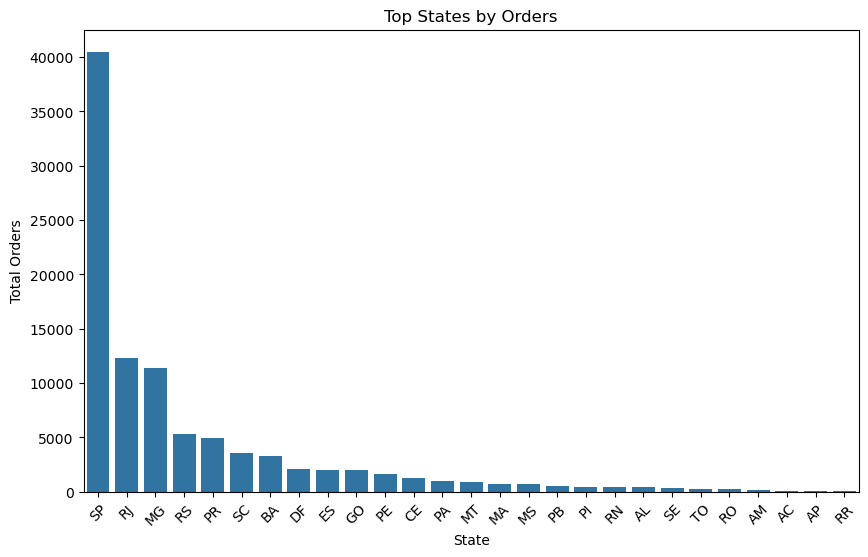

In [34]:
# Merge orders with customers
merged = delivered_orders.merge(customers, on="customer_id")

# Calculate number of orders for each city/state
top_states = merged.groupby(["customer_state", "customer_city"])["order_id"].count().reset_index()
top_states = top_states.sort_values(by="order_id", ascending=False)

print(top_states.head(10))

# Chart of top states by number of orders
state_counts = merged.groupby("customer_state")["order_id"].count().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=state_counts.index, y=state_counts.values)
plt.title("Top States by Orders")
plt.xlabel("State")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.show()

delivery_status
On Time    88644
Late        7826
Name: count, dtype: int64


C:\Users\Best By\AppData\Local\Temp\ipykernel_6288\1245446366.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivered_orders["delivery_status"] = delivered_orders.apply(


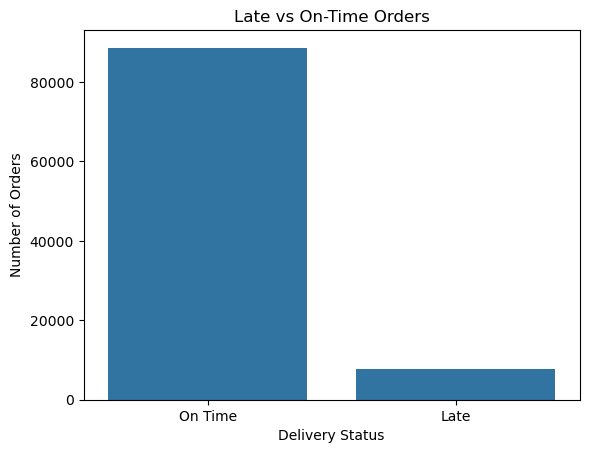

In [35]:
# Classify orders
delivered_orders["delivery_status"] = delivered_orders.apply(
    lambda row: "On Time" if row["order_delivered_customer_date"] <= row["order_estimated_delivery_date"] else "Late",
    axis=1
)

# Count the categories
status_counts = delivered_orders["delivery_status"].value_counts()
print(status_counts)

# Visualization
sns.barplot(x=status_counts.index, y=status_counts.values)
plt.title("Late vs On-Time Orders")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.show()

C:\Users\Best By\AppData\Local\Temp\ipykernel_6288\960794164.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivered_orders["shipping_lead_time"] = (


Average Shipping Lead Time (days): 2.2957123012170597


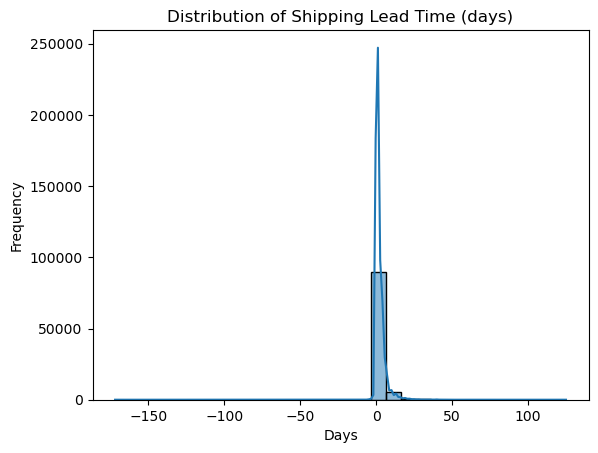

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the relevant columns to datetime
orders["order_delivered_carrier_date"] = pd.to_datetime(orders["order_delivered_carrier_date"], errors="coerce")
orders["order_approved_at"] = pd.to_datetime(orders["order_approved_at"], errors="coerce")

# Filter delivered orders only
delivered_orders = orders[(orders["order_status"] == "delivered") & (orders["order_delivered_carrier_date"].notna())]

# Calculate shipping lead time (from approval to carrier pickup)
delivered_orders["shipping_lead_time"] = (
    delivered_orders["order_delivered_carrier_date"] - delivered_orders["order_approved_at"]
).dt.days

# Average shipping lead time
avg_shipping_lead = delivered_orders["shipping_lead_time"].mean()
print("Average Shipping Lead Time (days):", avg_shipping_lead)

# Distribution chart
sns.histplot(delivered_orders["shipping_lead_time"].dropna(), bins=30, kde=True)
plt.title("Distribution of Shipping Lead Time (days)")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()